# 02 - Building Spaces: Simplicial and CW Complexes

Construct topological spaces from scratch with maximal simplices, understand closure properties, and visualize boundary matrices.

## Learning Goals
- Build simplicial complexes programmatically
- Understand closure under faces
- Read and interpret boundary matrices
- Visualize complex structures
- Convert between Simplicial and CW representations

## Setup

In [1]:
import matplotlib.pyplot as plt
import pysurgery as ps
print('=' * 70)
print('02 - Building Spaces: Simplicial and CW Complexes')
print('=' * 70 + '\n')

02 - Building Spaces: Simplicial and CW Complexes



## Part 1: Simplicial Complexes from Maximal Simplices

### Toy: Single Triangle

In [2]:
sc = ps.SimplicialComplex.from_maximal_simplices([(0,1,2)])
print(f'Vertices: {sc.f_vector()[0]}, Edges: {sc.f_vector()[1]}, Faces: {sc.f_vector()[2]}')
print(f'All 0-cells: {list(range(3))}')
print(f'All 1-cells (edges): {[(0,1), (0,2), (1,2)]}')
print(f'All 2-cells (faces): {[(0,1,2)]}')

Vertices: 3, Edges: 3, Faces: 1
All 0-cells: [0, 1, 2]
All 1-cells (edges): [(0, 1), (0, 2), (1, 2)]
All 2-cells (faces): [(0, 1, 2)]


### Medium: Two Triangles Sharing Edge

In [4]:
sc2 = ps.SimplicialComplex.from_maximal_simplices([(0,1,2), (1,2,3)])
print(f'f-vector: {sc2.f_vector()}')
print('Vertices: 0,1,2,3 (4 total)')
print('Edges: (0,1),(0,2),(1,2),(1,3),(2,3) (5 total)')
print('Faces: (0,1,2),(1,2,3) (2 total)')

f-vector: {0: 4, 1: 5, 2: 2}
Vertices: 0,1,2,3 (4 total)
Edges: (0,1),(0,2),(1,2),(1,3),(2,3) (5 total)
Faces: (0,1,2),(1,2,3) (2 total)


### Complex: Torus Approximation

In [5]:
torus = ps.SimplicialComplex.from_maximal_simplices([
    (0,1,2),(1,2,3),(2,3,4),(3,4,5),(4,5,6),(5,6,0),(6,0,1),
    (0,3,5),(1,4,6),(2,5,0)])
print(f'Torus f-vector: {torus.f_vector()}')
print(f'Euler: {torus.euler_characteristic()} (should be 0 for torus)')

Torus f-vector: {0: 7, 1: 17, 2: 10}
Euler: 0 (should be 0 for torus)


## Part 2: Boundary Matrices

### Understanding Boundary Operators

In [9]:
sc = ps.SimplicialComplex.from_maximal_simplices([(0,1,2)])
cc = sc.cellular_chain_complex()
d1 = sc.boundary_matrix(1)
d2 = sc.boundary_matrix(2)
print('Boundary matrix d_1 (edges → vertices):')
print(d1.toarray())
print('\nBoundary matrix d_2 (faces → edges):')
print(d2.toarray())

Boundary matrix d_1 (edges → vertices):
[[-1 -1  0]
 [ 1  0 -1]
 [ 0  1  1]]

Boundary matrix d_2 (faces → edges):
[[ 1]
 [-1]
 [ 1]]


### Verify Exactness

In [10]:
prod = d1 @ d2
print(f'Is d_1 ∘ d_2 = 0? {prod.nnz == 0} (nnz={prod.nnz})')
print('✓ Exactness verified: boundary of boundary is zero')

Is d_1 ∘ d_2 = 0? True (nnz=0)
✓ Exactness verified: boundary of boundary is zero


## Part 3: Visualization

✓ Visualization saved
✓ Visualization saved


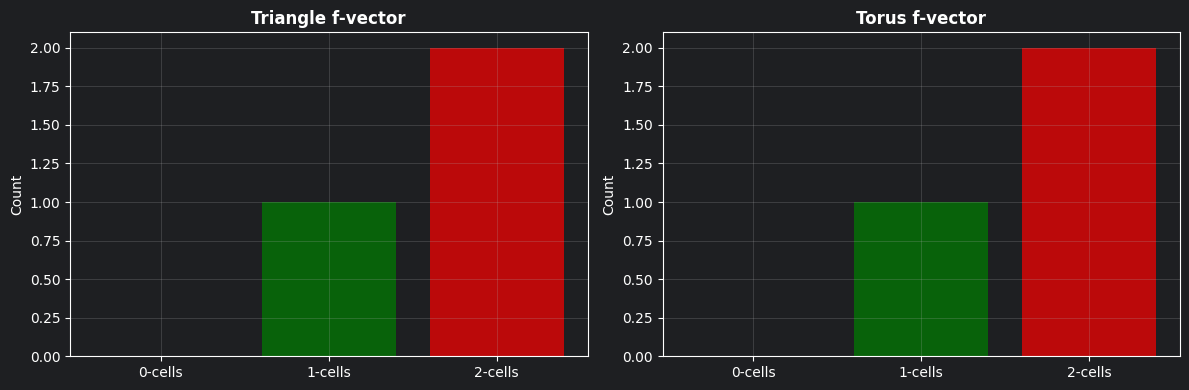

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
spaces = {'Triangle': sc, 'Torus': torus}
for idx, (name, space) in enumerate(spaces.items()):
    ax = axes[idx]
    fv = space.f_vector()
    ax.bar(['0-cells', '1-cells', '2-cells'], fv, color=['blue', 'green', 'red'], alpha=0.7)
    ax.set_title(f'{name} f-vector', fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/tmp/spaces_fvector.png', dpi=100, bbox_inches='tight')
    print('✓ Visualization saved')

## Formal Grounding Checkpoint

- A simplicial chain complex is $C_n(K;\mathbb{Z})$ with boundary maps $\partial_n$ satisfying $\partial^2=0$.
- Homology is computed by $H_n(K)=\ker(\partial_n)/\operatorname{im}(\partial_{n+1})$.
- CW attachments are controlled by attaching maps $\varphi:S^{n-1}\to X^{(n-1)}$.

| Construction piece | Formal object | Why it matters |
|---|---|---|
| Simplices | $[v_0,\dots,v_n]$ | Generates chain groups exactly |
| Boundary matrix | Integer matrix for $\partial_n$ | Input to exact SNF workflows |
| CW cell attachment | Pushout with $D^n$ and $S^{n-1}$ | Encodes global topology from local gluing |
